In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [7]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [8]:
DATA_FILE = "../data/processed/speech_features_normalized.csv"

df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
print(df["dataset"].value_counts())
print(df["emotion"].value_counts())

Shape: (10322, 51)
dataset
CREMA-D    7442
RAVDESS    2880
Name: count, dtype: int64
emotion
angry        1655
disgust      1655
fearful      1655
happy        1655
sad          1655
neutral      1279
calm          384
surprised     384
Name: count, dtype: int64


In [9]:
exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols].values.astype(np.float32)

emotion_encoder = LabelEncoder()
y_emotion = emotion_encoder.fit_transform(df["emotion"])

domain_encoder = LabelEncoder()
y_domain = domain_encoder.fit_transform(df["dataset"])

print("Features:", len(feature_cols))
print("X:", X.shape)
print("Emotions:", emotion_encoder.classes_)
print("Domains:", domain_encoder.classes_)

Features: 45
X: (10322, 45)
Emotions: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Domains: ['CREMA-D' 'RAVDESS']


In [10]:
stratify_labels = (
    df["dataset"].astype(str)
    + "_"
    + df["emotion"].astype(str)
)

X_train, X_test, y_emotion_train, y_emotion_test, y_domain_train, y_domain_test = train_test_split(
    X,
    y_emotion,
    y_domain,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (8257, 45)
Test : (2065, 45)


In [11]:
class SpeechDataset(Dataset):

    def __init__(self, X, y_emotion, y_domain):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_emotion = torch.tensor(
            y_emotion,
            dtype=torch.long
        )
        self.y_domain = torch.tensor(
            y_domain,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y_emotion[idx],
            self.y_domain[idx]
        )

In [12]:
train_dataset = SpeechDataset(
    X_train,
    y_emotion_train,
    y_domain_train
)

test_dataset = SpeechDataset(
    X_test,
    y_emotion_test,
    y_domain_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [13]:
class GradientReversalFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class GradientReversal(nn.Module):

    def __init__(self):
        super().__init__()
        self.lambda_ = 0.0

    def forward(self, x):
        return GradientReversalFunction.apply(
            x,
            self.lambda_
        )

In [14]:
class DANN(nn.Module):

    def __init__(
        self,
        input_dim,
        num_emotions,
        num_domains
    ):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )

        self.emotion_classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_emotions)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_domains)
        )

        self.grl = GradientReversal()

    def forward(self, x, lambda_=0.0):

        features = self.feature_extractor(x)

        emotion_output = self.emotion_classifier(
            features
        )

        self.grl.lambda_ = lambda_

        reversed_features = self.grl(features)

        domain_output = self.domain_classifier(
            reversed_features
        )

        return (
            emotion_output,
            domain_output,
            features
        )

In [15]:
def evaluate_model(model):

    model.eval()

    emotion_preds = []
    emotion_true = []

    domain_preds = []
    domain_true = []

    with torch.no_grad():

        for X_batch, y_emotion_batch, y_domain_batch in test_loader:

            X_batch = X_batch.to(device)

            emotion_output, domain_output, _ = model(
                X_batch,
                lambda_=0.0
            )

            emotion_pred = emotion_output.argmax(dim=1)
            domain_pred = domain_output.argmax(dim=1)

            emotion_preds.extend(
                emotion_pred.cpu().numpy()
            )

            emotion_true.extend(
                y_emotion_batch.numpy()
            )

            domain_preds.extend(
                domain_pred.cpu().numpy()
            )

            domain_true.extend(
                y_domain_batch.numpy()
            )

    emotion_acc = accuracy_score(
        emotion_true,
        emotion_preds
    )

    emotion_f1 = f1_score(
        emotion_true,
        emotion_preds,
        average="macro"
    )

    domain_acc = accuracy_score(
        domain_true,
        domain_preds
    )

    return emotion_acc, emotion_f1, domain_acc

In [16]:
def train_dann(lambda_max, epochs=40):

    model = DANN(
        input_dim=X_train.shape[1],
        num_emotions=len(emotion_encoder.classes_),
        num_domains=len(domain_encoder.classes_)
    ).to(device)

    emotion_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    for epoch in range(epochs):

        model.train()

        p = epoch / max(epochs - 1, 1)

        lambda_ = lambda_max * (
            2 / (1 + np.exp(-10 * p)) - 1
        )

        for X_batch, y_emotion_batch, y_domain_batch in train_loader:

            X_batch = X_batch.to(device)
            y_emotion_batch = y_emotion_batch.to(device)
            y_domain_batch = y_domain_batch.to(device)

            optimizer.zero_grad()

            emotion_output, domain_output, _ = model(
                X_batch,
                lambda_=lambda_
            )

            emotion_loss = emotion_criterion(
                emotion_output,
                y_emotion_batch
            )

            domain_loss = domain_criterion(
                domain_output,
                y_domain_batch
            )

            loss = emotion_loss + domain_loss

            loss.backward()

            optimizer.step()

    emotion_acc, emotion_f1, domain_acc = evaluate_model(model)

    return model, emotion_acc, emotion_f1, domain_acc

In [17]:
def train_dann(lambda_max, epochs=40):

    model = DANN(
        input_dim=X_train.shape[1],
        num_emotions=len(emotion_encoder.classes_),
        num_domains=len(domain_encoder.classes_)
    ).to(device)

    emotion_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    for epoch in range(epochs):

        model.train()

        p = epoch / max(epochs - 1, 1)

        lambda_ = lambda_max * (
            2 / (1 + np.exp(-10 * p)) - 1
        )

        for X_batch, y_emotion_batch, y_domain_batch in train_loader:

            X_batch = X_batch.to(device)
            y_emotion_batch = y_emotion_batch.to(device)
            y_domain_batch = y_domain_batch.to(device)

            optimizer.zero_grad()

            emotion_output, domain_output, _ = model(
                X_batch,
                lambda_=lambda_
            )

            emotion_loss = emotion_criterion(
                emotion_output,
                y_emotion_batch
            )

            domain_loss = domain_criterion(
                domain_output,
                y_domain_batch
            )

            loss = emotion_loss + domain_loss

            loss.backward()

            optimizer.step()

    emotion_acc, emotion_f1, domain_acc = evaluate_model(model)

    return model, emotion_acc, emotion_f1, domain_acc

In [18]:
lambda_values = [
    0.1,
    0.3,
    0.5,
    0.7,
    1.0
]

results = []

for lambda_max in lambda_values:

    print("=" * 60)
    print(f"Training λ = {lambda_max}")
    print("=" * 60)

    model, emotion_acc, emotion_f1, domain_acc = train_dann(
        lambda_max=lambda_max,
        epochs=40
    )

    results.append({
        "lambda": lambda_max,
        "emotion_accuracy": emotion_acc,
        "emotion_macro_f1": emotion_f1,
        "domain_accuracy": domain_acc
    })

    print(
        f"Emotion Accuracy: {emotion_acc:.4f}"
    )

    print(
        f"Emotion Macro F1: {emotion_f1:.4f}"
    )

    print(
        f"Domain Accuracy: {domain_acc:.4f}"
    )

Training λ = 0.1
Emotion Accuracy: 0.6557
Emotion Macro F1: 0.6954
Domain Accuracy: 0.9172
Training λ = 0.3
Emotion Accuracy: 0.6169
Emotion Macro F1: 0.6620
Domain Accuracy: 0.7884
Training λ = 0.5
Emotion Accuracy: 0.6339
Emotion Macro F1: 0.6696
Domain Accuracy: 0.7763
Training λ = 0.7
Emotion Accuracy: 0.6029
Emotion Macro F1: 0.6496
Domain Accuracy: 0.7642
Training λ = 1.0
Emotion Accuracy: 0.6145
Emotion Macro F1: 0.6517
Domain Accuracy: 0.7429


In [19]:
results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

 lambda  emotion_accuracy  emotion_macro_f1  domain_accuracy
    0.1          0.655690          0.695431         0.917191
    0.3          0.616949          0.662038         0.788378
    0.5          0.633898          0.669580         0.776271
    0.7          0.602906          0.649647         0.764165
    1.0          0.614528          0.651744         0.742857


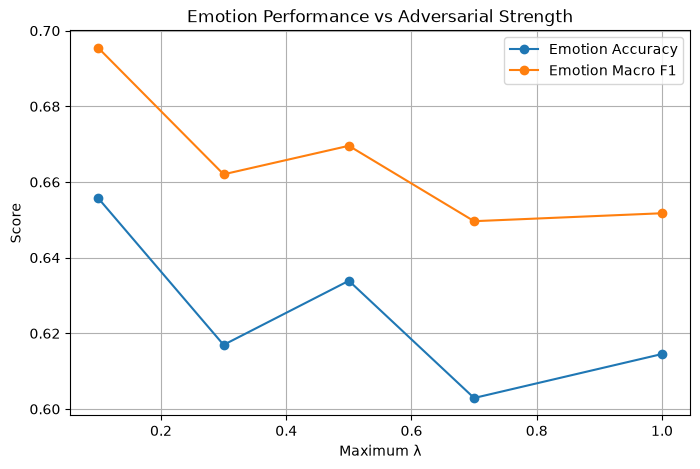

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["lambda"],
    results_df["emotion_accuracy"],
    marker="o",
    label="Emotion Accuracy"
)

plt.plot(
    results_df["lambda"],
    results_df["emotion_macro_f1"],
    marker="o",
    label="Emotion Macro F1"
)

plt.xlabel("Maximum λ")
plt.ylabel("Score")
plt.title("Emotion Performance vs Adversarial Strength")
plt.legend()
plt.grid(True)

plt.show()

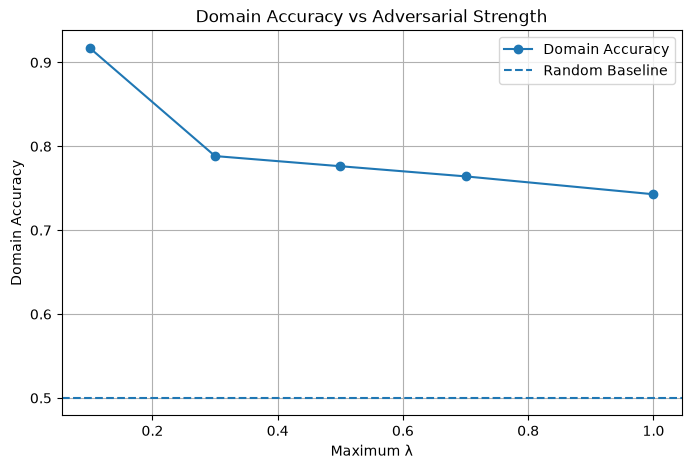

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["lambda"],
    results_df["domain_accuracy"],
    marker="o",
    label="Domain Accuracy"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random Baseline"
)

plt.xlabel("Maximum λ")
plt.ylabel("Domain Accuracy")
plt.title("Domain Accuracy vs Adversarial Strength")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
best_emotion = results_df.loc[
    results_df["emotion_macro_f1"].idxmax()
]

print("Best emotion model:")
print(best_emotion)

Best emotion model:
lambda              0.100000
emotion_accuracy    0.655690
emotion_macro_f1    0.695431
domain_accuracy     0.917191
Name: 0, dtype: float64


In [23]:
best_domain = results_df.loc[
    results_df["domain_accuracy"].idxmin()
]

print("Best domain invariance:")
print(best_domain)

Best domain invariance:
lambda              1.000000
emotion_accuracy    0.614528
emotion_macro_f1    0.651744
domain_accuracy     0.742857
Name: 4, dtype: float64


In [25]:
results_df["domain_invariance"] = (
    1 - abs(results_df["domain_accuracy"] - 0.5)
)

results_df["balanced_score"] = (
    0.7 * results_df["emotion_macro_f1"]
    + 0.3 * results_df["domain_invariance"]
)

print(
    results_df.sort_values(
        "balanced_score",
        ascending=False
    ).to_string(index=False)
)

 lambda  emotion_accuracy  emotion_macro_f1  domain_accuracy  domain_invariance  balanced_score
    0.5          0.633898          0.669580         0.776271           0.723729        0.685824
    1.0          0.614528          0.651744         0.742857           0.757143        0.683364
    0.3          0.616949          0.662038         0.788378           0.711622        0.676913
    0.7          0.602906          0.649647         0.764165           0.735835        0.675504
    0.1          0.655690          0.695431         0.917191           0.582809        0.661644


In [26]:
best_row = results_df.loc[
    results_df["balanced_score"].idxmax()
]

best_lambda = best_row["lambda"]

print("Best λ:", best_lambda)
print("Emotion accuracy:", best_row["emotion_accuracy"])
print("Emotion Macro F1:", best_row["emotion_macro_f1"])
print("Domain accuracy:", best_row["domain_accuracy"])
print("Balanced score:", best_row["balanced_score"])

Best λ: 0.5
Emotion accuracy: 0.6338983050847458
Emotion Macro F1: 0.6695796183427158
Domain accuracy: 0.7762711864406779
Balanced score: 0.6858243769076977
